# Règles complexes non linéaires induites par machine

## Référence

* **Titre exact :** *Complex nonlinear rules derived by autonomous machine learning systems*.
* **Contexte :** *Evidence-Based Technical Analysis* de David Aronson, chapitre sur les règles complexes et les combinaisons non additives.
* **Thème principal :** Utiliser des systèmes d'apprentissage automatique pour construire des règles de trading non linéaires à partir de règles simples ou d'indicateurs.

> Une règle complexe non linéaire ne se contente pas d'additionner des signaux simples. Elle apprend des **interactions conditionnelles** : un signal peut devenir utile seulement lorsque d'autres signaux sont dans un certain état.


## 1. Idée centrale

Dans ce passage, Aronson explique que les règles simples d'une étude de cas peuvent être combinées de manière **non linéaire** ou **non additive**.

Cela signifie que le modèle ne dit pas seulement :

$$
\text{Score} = a \times \text{Signal}_1 + b \times \text{Signal}_2 + c \times \text{Signal}_3
$$

Il peut apprendre une logique du type :

$$
\text{Acheter seulement si } \text{Momentum} > 0 \text{ ET } \text{Volatilité basse} \text{ ET } \text{Distance au VWAP favorable}
$$

Ou encore :

$$
\text{Le RSI bas est haussier dans un régime de retour à la moyenne, mais dangereux dans un régime de momentum baissier.}
$$

> La valeur d'un indicateur peut dépendre du contexte créé par les autres indicateurs. C'est exactement ce que les modèles non linéaires cherchent à capturer.


## 2. Pourquoi les modèles non linéaires sont puissants

Les marchés ne sont pas toujours bien décrits par des relations simples. Une règle linéaire suppose souvent qu'un signal a le même effet dans tous les contextes.

Exemple :

| Situation | RSI bas | Momentum | Interprétation possible |
|---|---:|---:|---|
| Marché en range | Oui | Neutre | Possible rebond |
| Marché en forte tendance baissière | Oui | Très négatif | Possible continuation baissière |

Le même RSI bas peut donc avoir deux significations opposées.

Un modèle non linéaire peut apprendre cette différence, car il ne cherche pas seulement l'effet isolé du RSI. Il cherche aussi les **interactions** entre RSI, momentum, volatilité, tendance, volume, distance au VWAP, etc.


## 3. Les systèmes mentionnés par Aronson

Aronson cite plusieurs familles de systèmes d'apprentissage automatique capables de construire ce type de règles :

| Famille | Intuition | Exemple de logique apprise |
|---|---|---|
| **Réseaux de neurones** | Approximation flexible de relations complexes | Frontières non linéaires entre régimes favorables et défavorables |
| **Arbres de décision** | Suite de règles conditionnelles | Si volatilité basse, puis si momentum positif, puis signal long |
| **Ensembles d'arbres** | Agrégation de nombreux arbres | Forêts aléatoires, boosting |
| **Splines de régression** | Relations lisses mais non linéaires | Effet progressif puis saturé d'un indicateur |
| **Kernel regression** | Similarité avec des cas historiques | Prédiction à partir de situations passées ressemblantes |
| **Réseaux polynomiaux** | Interactions explicites entre variables | $\text{Momentum} \times \text{Volatilité}$ |
| **Programmation génétique** | Recherche automatique de formules | Création de règles symboliques complexes |
| **SVM** | Séparation avec marge maximale | Frontière non linéaire via kernel |

Le point commun : ces méthodes utilisent une forme d'**inductive generalization**.

Elles apprennent à partir d'exemples historiques pour produire une règle générale applicable à de nouveaux cas.


## 4. Ce qu'est un exemple historique

Dans le passage, Aronson définit chaque exemple comme un **case**.

Un cas est une ligne de données à une date donnée :

| Date | Indicateur 1 | Indicateur 2 | Règle 1 | Règle 2 | Outcome futur |
|---|---:|---:|---:|---:|---:|
| 2020-01-03 | RSI = 42 | Momentum = 1.2\% | 1 | 0 | +0.8\% |
| 2020-01-04 | RSI = 70 | Momentum = -0.5\% | 0 | -1 | -0.4\% |

La variable cible peut être par exemple :

$$
Y_t = \text{rendement futur sur } h \text{ périodes}
$$

ou une cible binaire :

$$
Y_t =
\begin{cases}
1 & \text{si le rendement futur est positif} \\
0 & \text{sinon}
\end{cases}
$$

> Le modèle apprend une correspondance entre l'état du marché aujourd'hui et l'issue future mesurée objectivement.


## 5. Deux manières de construire les inputs

Aronson distingue deux approches.

### Approche A — Donner au modèle les règles simples en forme binaire

Chaque règle simple devient une variable d'entrée.

Exemple :

| Date | Règle momentum | Règle RSI | Règle breakout | Rendement futur |
|---|---:|---:|---:|---:|
| t | 1 | 0 | 1 | +0.6\% |
| t+1 | 0 | 1 | 0 | -0.2\% |

Ici, le modèle apprend à combiner des décisions déjà simplifiées.

### Approche B — Donner au modèle les indicateurs bruts

Au lieu de donner directement les règles, on donne les variables continues :

| Date | RSI | Momentum 20j | Volatilité | Distance VWAP | Rendement futur |
|---|---:|---:|---:|---:|---:|
| t | 42 | 1.8\% | 0.9\% | -0.4\% | +0.6\% |
| t+1 | 70 | -0.5\% | 1.5\% | +0.8\% | -0.2\% |

Ici, le modèle apprend lui-même les seuils, les interactions et les formes non linéaires.


## 6. Comparaison des deux approches

| Approche | Avantage | Limite |
|---|---|---|
| **Règles binaires comme inputs** | Plus simple, plus interprétable, moins de degrés de liberté | Perte d'information à cause des seuils déjà fixés |
| **Indicateurs bruts comme inputs** | Plus flexible, peut découvrir ses propres seuils | Plus gros risque de **data-mining bias** et d'**overfitting** |

> Plus le modèle est flexible, plus il peut découvrir une vraie structure. Mais plus il peut aussi apprendre du bruit historique.


## 7. Exemple Python — Données synthétiques de marché

Nous allons simuler un petit dataset de trading avec :

* un prix ;
* un indicateur de momentum ;
* un RSI simplifié ;
* une volatilité ;
* des règles binaires dérivées ;
* une cible : le rendement futur.

Le but n'est pas de créer une vraie stratégie rentable, mais de montrer la différence entre :

1. **inputs = règles binaires** ;
2. **inputs = indicateurs bruts**.


In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 1500
returns = np.random.normal(loc=0.0002, scale=0.01, size=n)
price = 100 * np.exp(np.cumsum(returns))

df = pd.DataFrame({
    "close": price
})

# Rendements passés
df["ret_1"] = df["close"].pct_change()
df["mom_10"] = df["close"].pct_change(10)
df["mom_20"] = df["close"].pct_change(20)

# Volatilité réalisée simplifiée
df["vol_20"] = df["ret_1"].rolling(20).std()

# RSI simplifié
delta = df["close"].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
rs = gain / loss
df["rsi_14"] = 100 - (100 / (1 + rs))

# Cible : rendement futur à 5 périodes
df["future_ret_5"] = df["close"].pct_change(5).shift(-5)
df["target_up"] = (df["future_ret_5"] > 0).astype(int)

df = df.dropna().copy()
df.head()


,close,ret_1,mom_10,mom_20,vol_20,rsi_14,future_ret_5,target_up
20,98.471480,0.014967,-0.056138,-0.020360,0.010176,28.144361,-0.018982,0
21,98.269057,-0.002056,-0.053870,-0.021217,0.010179,22.611326,-0.028017,0
22,98.355108,0.000876,-0.055519,-0.026879,0.010029,24.138848,-0.025017,0
23,96.983125,-0.013949,-0.050894,-0.055146,0.009577,17.712177,-0.016949,0
24,96.475894,-0.005230,-0.039623,-0.058073,0.009591,17.648551,-0.014461,0


## 8. Créer des règles simples en forme binaire

Transformons les indicateurs bruts en règles simples.

Exemples :

$$
\text{Règle momentum} = 1 \text{ si } \text{momentum}_{20} > 0
$$

$$
\text{Règle RSI bas} = 1 \text{ si } \text{RSI}_{14} < 40
$$

$$
\text{Règle volatilité basse} = 1 \text{ si } \text{volatilité}_{20} < \text{médiane historique}
$$


In [2]:
vol_median = df["vol_20"].median()

# Règles binaires simples
df["rule_momentum_positive"] = (df["mom_20"] > 0).astype(int)
df["rule_rsi_low"] = (df["rsi_14"] < 40).astype(int)
df["rule_rsi_high"] = (df["rsi_14"] > 60).astype(int)
df["rule_low_vol"] = (df["vol_20"] < vol_median).astype(int)

binary_features = [
    "rule_momentum_positive",
    "rule_rsi_low",
    "rule_rsi_high",
    "rule_low_vol"
]

raw_features = [
    "mom_10",
    "mom_20",
    "vol_20",
    "rsi_14"
]

df[binary_features + raw_features + ["target_up"]].head()


,rule_momentum_positive,rule_rsi_low,rule_rsi_high,rule_low_vol,mom_10,mom_20,vol_20,rsi_14,target_up
20,0,1,0,0,-0.056138,-0.020360,0.010176,28.144361,0
21,0,1,0,0,-0.053870,-0.021217,0.010179,22.611326,0
22,0,1,0,0,-0.055519,-0.026879,0.010029,24.138848,0
23,0,1,0,1,-0.050894,-0.055146,0.009577,17.712177,0
24,0,1,0,1,-0.039623,-0.058073,0.009591,17.648551,0


## 9. Train / Test / Validation OOS

Dans l'esprit EBTA, il faut éviter de juger le modèle sur les mêmes données que celles utilisées pour le construire.

Nous découpons donc le dataset chronologiquement :

| Segment | Rôle |
|---|---|
| **Train** | Apprendre les paramètres du modèle |
| **Test** | Comparer les modèles et choisir la complexité |
| **Validation OOS** | Estimation finale non contaminée |

> La validation OOS ne doit pas devenir une nouvelle zone de recherche. Sinon, elle perd son rôle de preuve externe.


In [3]:
def chronological_split(data, train_size=0.60, test_size=0.20):
    n = len(data)
    train_end = int(n * train_size)
    test_end = int(n * (train_size + test_size))
    train = data.iloc[:train_end].copy()
    test = data.iloc[train_end:test_end].copy()
    validation = data.iloc[test_end:].copy()
    return train, test, validation

train, test, validation = chronological_split(df)

len(train), len(test), len(validation)


(885, 295, 295)

## 10. Modèle non linéaire avec règles binaires comme inputs

Nous utilisons ici un **arbre de décision** simple.

Un arbre est pédagogique parce qu'il apprend directement des règles conditionnelles du type :

$$
\text{Si momentum positif, puis si volatilité basse, alors probabilité de hausse = x}
$$

Il est donc très proche de l'idée de **règle complexe non additive**.


In [4]:
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score, roc_auc_score

X_train_bin = train[binary_features]
y_train = train["target_up"]

X_test_bin = test[binary_features]
y_test = test["target_up"]

X_val_bin = validation[binary_features]
y_val = validation["target_up"]

# max_depth limite la complexité pour réduire l'overfitting
model_bin = DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, random_state=42)
model_bin.fit(X_train_bin, y_train)

for name, X, y in [
    ("Train", X_train_bin, y_train),
    ("Test", X_test_bin, y_test),
    ("Validation OOS", X_val_bin, y_val),
]:
    pred = model_bin.predict(X)
    proba = model_bin.predict_proba(X)[:, 1]
    print(name)
    print("Accuracy:", round(accuracy_score(y, pred), 4))
    print("AUC:", round(roc_auc_score(y, proba), 4))
    print()

print(export_text(model_bin, feature_names=binary_features))


Train
Accuracy: 0.5514
AUC: 0.5674

Test
Accuracy: 0.539
AUC: 0.5094

Validation OOS
Accuracy: 0.4712
AUC: 0.4222

|--- rule_rsi_low <= 0.50
|   |--- rule_low_vol <= 0.50
|   |   |--- rule_momentum_positive <= 0.50
|   |   |   |--- class: 1
|   |   |--- rule_momentum_positive >  0.50
|   |   |   |--- class: 0
|   |--- rule_low_vol >  0.50
|   |   |--- rule_momentum_positive <= 0.50
|   |   |   |--- class: 1
|   |   |--- rule_momentum_positive >  0.50
|   |   |   |--- class: 1
|--- rule_rsi_low >  0.50
|   |--- rule_low_vol <= 0.50
|   |   |--- class: 0
|   |--- rule_low_vol >  0.50
|   |   |--- class: 0



## 11. Modèle non linéaire avec indicateurs bruts comme inputs

Maintenant, nous donnons au modèle les indicateurs continus.

Le modèle peut apprendre lui-même :

* les seuils utiles ;
* les zones de transition ;
* les interactions ;
* les combinaisons conditionnelles.

Mais il a aussi plus de liberté, donc plus de risque d'**overfitting**.


In [5]:
X_train_raw = train[raw_features]
X_test_raw = test[raw_features]
X_val_raw = validation[raw_features]

model_raw = DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, random_state=42)
model_raw.fit(X_train_raw, y_train)

for name, X, y in [
    ("Train", X_train_raw, y_train),
    ("Test", X_test_raw, y_test),
    ("Validation OOS", X_val_raw, y_val),
]:
    pred = model_raw.predict(X)
    proba = model_raw.predict_proba(X)[:, 1]
    print(name)
    print("Accuracy:", round(accuracy_score(y, pred), 4))
    print("AUC:", round(roc_auc_score(y, proba), 4))
    print()

print(export_text(model_raw, feature_names=raw_features))


Train
Accuracy: 0.5853
AUC: 0.5934

Test
Accuracy: 0.5525
AUC: 0.5021

Validation OOS
Accuracy: 0.6102
AUC: 0.5037

|--- vol_20 <= 0.01
|   |--- class: 1
|--- vol_20 >  0.01
|   |--- rsi_14 <= 36.95
|   |   |--- vol_20 <= 0.01
|   |   |   |--- class: 0
|   |   |--- vol_20 >  0.01
|   |   |   |--- class: 0
|   |--- rsi_14 >  36.95
|   |   |--- vol_20 <= 0.01
|   |   |   |--- class: 1
|   |   |--- vol_20 >  0.01
|   |   |   |--- class: 0



## 12. Visualiser la différence entre complexité utile et surapprentissage

Un modèle plus profond peut sembler meilleur sur le **train**, mais se dégrader sur le **test** et la **validation OOS**.

C'est exactement le danger EBTA : confondre une vraie régularité avec un artefact produit par la recherche dans les données.


In [6]:
results = []

for depth in range(1, 11):
    model = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=20, random_state=42)
    model.fit(X_train_raw, y_train)
    
    for split_name, X, y in [
        ("Train", X_train_raw, y_train),
        ("Test", X_test_raw, y_test),
        ("Validation OOS", X_val_raw, y_val),
    ]:
        proba = model.predict_proba(X)[:, 1]
        auc = roc_auc_score(y, proba)
        results.append({
            "max_depth": depth,
            "split": split_name,
            "auc": auc
        })

results_df = pd.DataFrame(results)
results_df.pivot(index="max_depth", columns="split", values="auc").round(4)


split,Test,Train,Validation OOS
max_depth,,,
1,0.4984,0.5324,0.4777
2,0.4804,0.5477,0.4554
3,0.4630,0.5713,0.4999
4,0.4801,0.6042,0.5339
5,0.4394,0.6352,0.5352
6,0.4506,0.6696,0.5290
7,0.4577,0.6967,0.5560
8,0.4806,0.7151,0.5226
9,0.4633,0.7327,0.5052


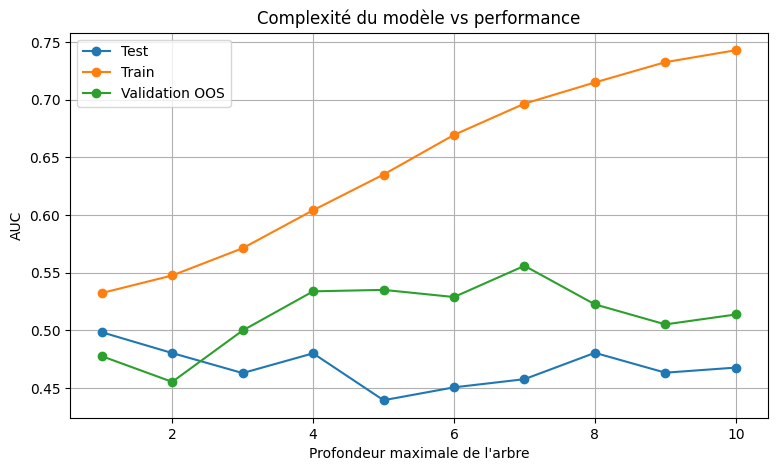

In [7]:
import matplotlib.pyplot as plt

pivot = results_df.pivot(index="max_depth", columns="split", values="auc")

plt.figure(figsize=(9, 5))
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], marker="o", label=col)

plt.title("Complexité du modèle vs performance")
plt.xlabel("Profondeur maximale de l'arbre")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.show()


## 13. Traduction trading concrète

Une règle simple ressemble à ceci :

$$
\text{Acheter si } \text{RSI} < 30
$$

Une règle complexe linéaire ressemble à ceci :

$$
\text{Score} = 0.4 \times \text{Momentum} - 0.2 \times \text{Volatilité} + 0.3 \times \text{Signal RSI}
$$

Une règle complexe non linéaire ressemble plutôt à ceci :

$$
\text{Acheter si } 
\begin{cases}
\text{Momentum positif} \\
\text{Volatilité basse} \\
\text{RSI pas trop haut} \\
\text{Distance au VWAP favorable}
\end{cases}
$$

Mais avec une nuance importante : le modèle peut apprendre que certaines conditions n'ont de valeur que dans certains régimes.

Exemple :

| Régime | Signal RSI bas | Décision possible |
|---|---|---|
| Range calme | Opportunité de rebond | Long possible |
| Momentum baissier fort | Couteau qui tombe | Éviter ou short |

> Le non-linéaire permet à la stratégie de dire : “ce signal est bon ici, mais mauvais là”.


## 14. Le piège EBTA : data-mining bias

Aronson précise que ces systèmes sont des systèmes de **data mining**.

Cela ne veut pas dire qu'ils sont mauvais. Cela veut dire qu'ils explorent beaucoup de possibilités.

Plus on explore :

* plusieurs modèles ;
* plusieurs hyperparamètres ;
* plusieurs indicateurs ;
* plusieurs horizons de prédiction ;
* plusieurs univers ;
* plusieurs coûts de transaction ;
* plusieurs périodes ;

plus on augmente la probabilité de trouver une performance apparemment excellente par hasard.

Le danger est donc :

$$
\text{Performance observée} = \text{vraie edge} + \text{chance} + \text{biais de recherche}
$$

> Le machine learning ne supprime pas le data-mining bias. Il peut l'amplifier si le protocole de validation est faible.


## 15. Checklist EBTA pour utiliser ces modèles proprement

| Étape | Question à poser |
|---|---|
| Hypothèse | Quelle inefficience ou prime comportementale le modèle cherche-t-il à capturer ? |
| Features | Les inputs sont-ils disponibles au moment de la décision ? |
| Cible | La variable prédite est-elle définie sans fuite du futur ? |
| Train | Les paramètres sont-ils appris uniquement sur le train ? |
| Test | La complexité est-elle choisie sans toucher à la validation finale ? |
| Validation OOS | La performance finale est-elle mesurée une seule fois ? |
| Coûts | Les frais, slippage et contraintes de liquidité sont-ils inclus ? |
| Multiplicité | Le nombre de modèles testés est-il documenté ? |
| Robustesse | La règle survit-elle aux changements raisonnables de période, marché et coûts ? |

Cette checklist est essentielle, car un modèle non linéaire peut facilement produire une belle histoire après coup.


## 16. Erreurs fréquentes

### Erreur 1 — Croire que le machine learning crée automatiquement une edge

Un modèle flexible peut apprendre du bruit avec une très grande efficacité.

### Erreur 2 — Optimiser sur la validation OOS

Si la validation OOS sert à ajuster le modèle, elle n'est plus OOS.

### Erreur 3 — Confondre précision statistique et rentabilité tradable

Une AUC légèrement supérieure à $0.5$ ne suffit pas. Il faut intégrer les coûts, le sizing, le turnover et le risque.

### Erreur 4 — Utiliser des features indisponibles en temps réel

Exemple : utiliser une donnée de clôture pour simuler une décision prise avant la clôture.

### Erreur 5 — Tester trop de modèles sans correction

Chaque essai augmente la chance de sélectionner une règle gagnante par hasard.


## 17. Eurêka final

> Une règle complexe non linéaire est une machine qui apprend les conditions dans lesquelles les signaux simples deviennent utiles ou dangereux.

Mais dans l'esprit EBTA, la vraie question n'est pas :

> “Est-ce que le modèle trouve une belle performance dans l'historique ?”

La vraie question est :

> “Après avoir tenu compte de la recherche, de la complexité, des coûts et de la validation hors échantillon, reste-t-il une performance crédible ?”

C'est cette différence qui sépare le **machine learning scientifique** du simple **data mining narratif**.


## Annexe — Texte source collé

```text
Complex rules that
combine simple rules in a nonlinear or nonadditive fashion could also be
derived from the case study's rules. However, this would require the use of
autonomous machine learning (data-mining) systems such as neural networks,
12 decision trees and decision tree ensembles, multiple regression
splines,13 kernel regression,14 polynomial networks,15 genetic programming,
16 support-vector machines,17 and so on. These systems employ inductive
generalization to synthesize a complex nonlinear rule (model) by
learning from a large set of historical examples. Each example is a a case,
characterized by a set of indicator values as of a given date and the value
of an outcome variable that the model is intended to predict.
Complex nonlinear rules could be derived in two ways. One would be
to submit the rules in binary form, as the candidate inputs. A second approach
would be to submit the indicators used by the rules.
```
